# Phase 2: Exploratory Data Analysis (EDA)
**Project:** Autonomous Software Repair: A RAG-Augmented Agent for Real-Time Vulnerability Patching in CI/CD Pipelines

## 1. Data Loading and Preparation
For this EDA, we are loading the **SWE-bench Lite** dataset directly from Hugging Face. This dataset contains real-world GitHub issues (`problem_statement`) and the actual code fixes (`patch`) that resolved them.

In [ ]:
# Install the necessary library to fetch the dataset
!pip install datasets -q
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

# Load SWE-bench Lite dataset
print("Downloading dataset...")
dataset = load_dataset("princeton-nlp/SWE-bench_Lite", split="test")

# Convert to a Pandas DataFrame for easier analysis
df = pd.DataFrame(dataset)

# Feature Engineering for EDA: Calculate word counts and line counts
df['issue_word_count'] = df['problem_statement'].apply(lambda x: len(str(x).split()))
df['patch_line_count'] = df['patch'].apply(lambda x: len(str(x).split('\n')))

print(f"Dataset loaded! Total issues analyzed: {len(df)}")
df[['instance_id', 'repo', 'issue_word_count', 'patch_line_count']].head()

README.md: 0.00B [00:00, ?B/s]

data/dev-00000-of-00001.parquet:   0%|          | 0.00/120k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.12M [00:00<?, ?B/s]

Generating dev split:   0%|          | 0/23 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/300 [00:00<?, ? examples/s]

Dataset loaded! Total issues analyzed: 300


,instance_id,repo,issue_word_count,patch_line_count
0,astropy__astropy-12907,astropy/astropy,158,13
1,astropy__astropy-14182,astropy/astropy,189,67
2,astropy__astropy-14365,astropy/astropy,202,22
3,astropy__astropy-14995,astropy/astropy,357,17
4,astropy__astropy-6938,astropy/astropy,76,13


## 2. Descriptive Statistics
Before visualizing, we need to understand the central tendencies of our data.
* **Mean & Median Issue Length:** Helps us set the `max_tokens` limit for our RAG context retrieval.
* **Correlation:** Tells us if a "longer bug report" necessarily means a "larger code patch."

In [ ]:
# 1. Descriptive Statistics
stats = df[['issue_word_count', 'patch_line_count']].describe().round(2)
print("--- Basic Descriptive Statistics ---")
print(stats)
print("\n")

# Calculate medians specifically (less sensitive to massive outliers than mean)
median_issue = df['issue_word_count'].median()
median_patch = df['patch_line_count'].median()
print(f"Median Issue Word Count: {median_issue}")
print(f"Median Patch Line Count: {median_patch}\n")

# Calculate Correlation
correlation = df['issue_word_count'].corr(df['patch_line_count'])
print(f"Correlation between Issue Length and Patch Size: {correlation:.4f}")

--- Basic Descriptive Statistics ---
       issue_word_count  patch_line_count
count            300.00            300.00
mean             174.57             25.86
std              162.84             16.57
min               41.00             11.00
25%               88.75             15.00
50%              134.00             20.00
75%              208.00             31.00
max             1892.00            120.00


Median Issue Word Count: 134.0
Median Patch Line Count: 20.0

Correlation between Issue Length and Patch Size: -0.0450


## 3. Visual Discovery
We will generate three distinct visualizations to identify trends and constraints for our Autonomous Agent.

### Visual 1: Bar Chart (Repository Distribution)
**Purpose:** To see which Python frameworks our agent will be tested on the most. If one repository dominates the dataset, we must ensure our RAG pipeline is optimized for that specific framework's documentation (e.g., Django vs. Scikit-learn).

/tmp/ipython-input-2167697186.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=repo_counts.values, y=repo_counts.index, palette="viridis")


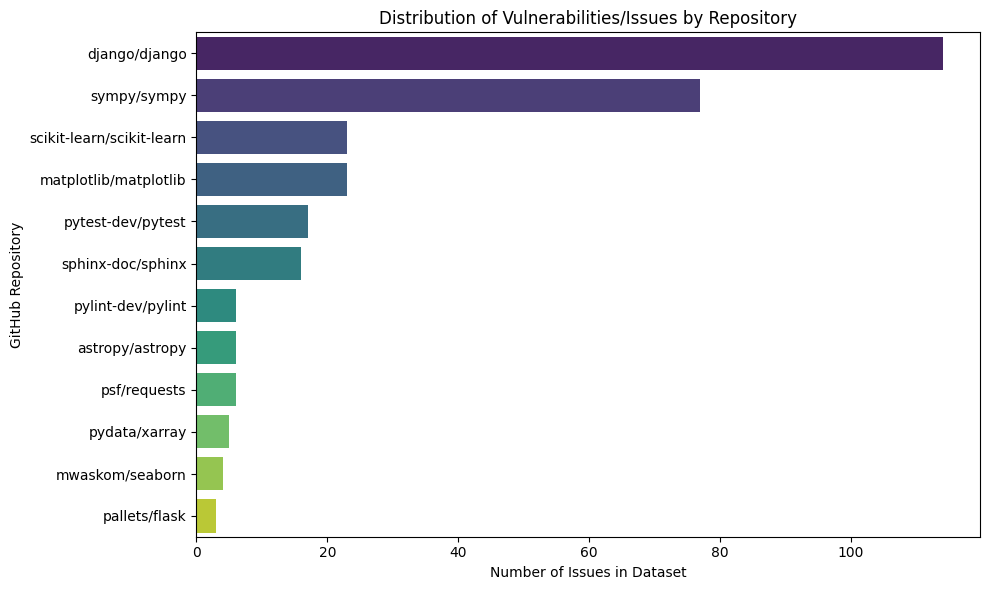

In [ ]:
plt.figure(figsize=(10, 6))
repo_counts = df['repo'].value_counts()
sns.barplot(x=repo_counts.values, y=repo_counts.index, palette="viridis")
plt.title("Distribution of Vulnerabilities/Issues by Repository")
plt.xlabel("Number of Issues in Dataset")
plt.ylabel("GitHub Repository")
plt.tight_layout()
plt.show()

### Visual 2: Histogram (Problem Statement Lengths)
**Purpose:** To understand the token constraints for our LLM. If the distribution shows massive bug reports, we cannot feed the entire text directly into a small LLM without truncation.

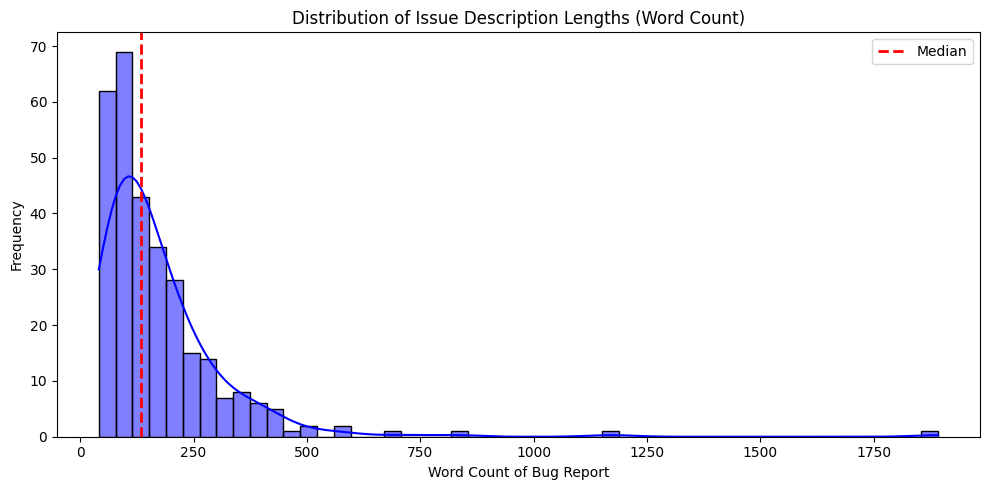

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df['issue_word_count'], bins=50, kde=True, color='blue')
plt.title("Distribution of Issue Description Lengths (Word Count)")
plt.xlabel("Word Count of Bug Report")
plt.ylabel("Frequency")
plt.axvline(df['issue_word_count'].median(), color='red', linestyle='dashed', linewidth=2, label='Median')
plt.legend()
plt.tight_layout()
plt.show()

### Visual 3: Scatter Plot (Issue Complexity vs. Patch Complexity)
**Purpose:** To determine if there is a linear relationship between how long an issue description is and how many lines of code it takes to fix it. If the correlation is low, it proves that even a one-sentence CVE report can require a massive architectural code fix.

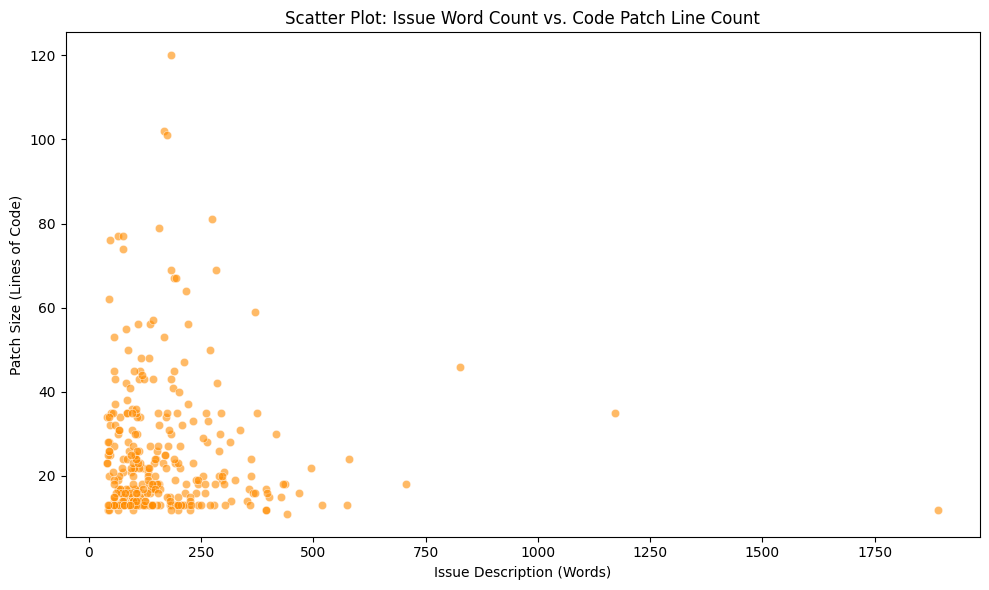

In [ ]:
plt.figure(figsize=(10, 6))
# We limit to patches < 500 lines to remove extreme outliers and see the cluster better
filtered_df = df[df['patch_line_count'] < 500]

sns.scatterplot(data=filtered_df, x='issue_word_count', y='patch_line_count', alpha=0.6, color='darkorange')
plt.title("Scatter Plot: Issue Word Count vs. Code Patch Line Count")
plt.xlabel("Issue Description (Words)")
plt.ylabel("Patch Size (Lines of Code)")
plt.tight_layout()
plt.show()